# IoT Threat Infrastructure -- Research Analysis Notebook

**Paper:** A Multi-Vantage Empirical Measurement of Internet-Exposed IoT Threat Infrastructure: Device Exposure, Attack Characterisation, and Proxy-Based Monetisation Indicators  
**Target:** IEEE Internet of Things Journal (Q1)  
**Data window:** April 6-25, 2026  

| Source | Records | Unique IPs |
|---|---|---|
| Shodan (Apr-6) | 6,002 | 3,855 |
| Shodan (Apr-20) | 10,385 | 9,510 |
| Censys (Apr-20) | 2,063 | 60 |
| Honeypots (Glutton/Cowrie/OpenCanary) | 8,407 events | 2,014 IPs |
| Threat Feeds (ThreatFox/URLhaus/OTX/MB) | 12,418 IOCs | 135 families |
| **TOTAL device records** | **18,450** | **13,425+** |


In [38]:
import os, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    'font.family': 'DejaVu Serif', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 120, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'savefig.pad_inches': 0.1,
    'axes.spines.top': False, 'axes.spines.right': False,
})

C_BLUE   = '#2166ac'; C_DKBLUE = '#053061'
C_RED    = '#d73027'; C_ORANGE = '#f46d43'
C_GREEN  = '#1a9850'; C_TEAL   = '#35978f'
C_PURPLE = '#762a83'; C_LGREY  = '#d9d9d9'

# notebooks run from research-notebook/; go up one level to repo root
NOTEBOOK_DIR = Path(os.getcwd()).resolve()
REPO = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'research-notebook' else NOTEBOOK_DIR
DIAG = REPO / 'research-paper' / 'diagrams'
DIAG.mkdir(parents=True, exist_ok=True)
print(f"Python  : {__import__('sys').version.split()[0]}")
print(f"Repo    : {REPO}")
print(f"Diagrams: {DIAG}")


Python  : 3.12.7
Repo    : /Users/faisal/Documents/Me_and_Myself/varsity-Course/488cse/Cyber-Security-Data-Analysis-Pipeline
Diagrams: /Users/faisal/Documents/Me_and_Myself/varsity-Course/488cse/Cyber-Security-Data-Analysis-Pipeline/research-paper/diagrams


In [39]:
DB_AVAILABLE = False
conn = None
try:
    import psycopg2
    conn = psycopg2.connect(host='localhost', port=5432, dbname='iotpipeline',
                            user='iotuser', password='iotpassword', connect_timeout=4)
    DB_AVAILABLE = True
    print('Connected to PostgreSQL -- live queries enabled')
except Exception as e:
    print(f'DB offline ({e.__class__.__name__}) -- using confirmed aggregate data')


DB offline (OperationalError) -- using confirmed aggregate data


## Section 1 -- Honeypot Event Analysis

In [40]:
HONEYPOT = {
    'Glutton':    {'events': 8302, 'ips': 2014, 'days': 3},
    'Cowrie':     {'events': 104,  'ips': 9,    'days': 1},
    'OpenCanary': {'events': 1,    'ips': 1,    'days': 1},
}
total_events = sum(v['events'] for v in HONEYPOT.values())
print('=' * 52)
print('  HONEYPOT SENSOR SUMMARY  (Apr 23-25, 2026)')
print('=' * 52)
print(f"  {'Sensor':<12} {'Events':>8} {'Unique IPs':>10} {'Days':>6}")
print('  ' + '-' * 40)
for name, d in HONEYPOT.items():
    print(f"  {name:<12} {d['events']:>8,}  {d['ips']:>9,}  {d['days']:>5}")
print('  ' + '-' * 40)
print(f"  {'TOTAL':<12} {total_events:>8,}  {'2,014+':>10}")
print()
print('  Top attacker: 85.11.167.11  (475 events, 5.7%)')
print('  Credential pairs observed: 10 unique')


  HONEYPOT SENSOR SUMMARY  (Apr 23-25, 2026)
  Sensor         Events Unique IPs   Days
  ----------------------------------------
  Glutton         8,302      2,014      3
  Cowrie            104          9      1
  OpenCanary          1          1      1
  ----------------------------------------
  TOTAL           8,407      2,014+

  Top attacker: 85.11.167.11  (475 events, 5.7%)
  Credential pairs observed: 10 unique


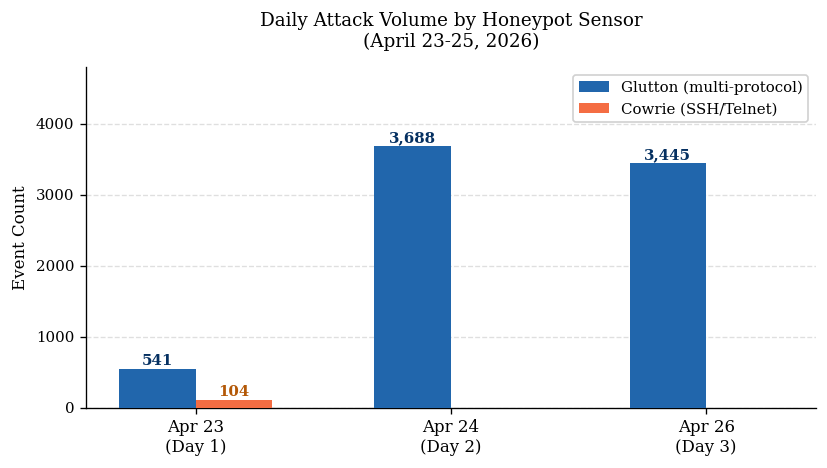

fig2_daily_volume saved


In [41]:
days    = ['Apr 23\n(Day 1)', 'Apr 24\n(Day 2)', 'Apr 26\n(Day 3)']
glutton = [541, 3688, 3445]
cowrie  = [104,    0,    0]
x = np.arange(3); w = 0.30

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, glutton, w, color=C_BLUE,   label='Glutton (multi-protocol)', zorder=3)
ax.bar(x + w/2, cowrie,  w, color=C_ORANGE, label='Cowrie (SSH/Telnet)',      zorder=3)
for xi, val in zip(x, glutton):
    ax.text(xi - w/2, val + 60, f'{val:,}', ha='center', fontsize=9,
            color=C_DKBLUE, fontweight='bold')
ax.text(x[0] + w/2, cowrie[0] + 60, '104', ha='center', fontsize=9,
        color='#b35806', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(days, fontsize=10)
ax.set_ylabel('Event Count')
ax.set_title('Daily Attack Volume by Honeypot Sensor\n(April 23-25, 2026)', pad=12)
ax.legend(loc='upper right', framealpha=0.9)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_ylim(0, 4800)
plt.tight_layout()
plt.savefig(DIAG / 'fig2_daily_volume.pdf')
plt.savefig(DIAG / 'fig2_daily_volume.png')
plt.show()
print('fig2_daily_volume saved')


In [42]:
top_ips = [('85.11.167.11',475),('176.120.22.73',451),('45.205.1.5',312),
           ('45.205.1.110',261),('152.53.81.25',198),('92.63.197.22',148),
           ('160.119.76.54',144),('93.123.72.166',126),('80.66.83.43',117),
           ('46.151.178.13',109)]
creds = [('casino','casino'),('root',''),('root','casino'),('casino','root'),
         ('bet','bet'),('admin','admin'),('amusnet','amusnet'),('testuser','testuser'),
         ('ada','111111'),('AdminGPON','ALC#FGU')]

print('=== Top 10 Attacker IPs ===')
for ip, h in top_ips:
    print(f'  {ip:<20} {h:>4} hits  ({h/8407*100:.1f}%)')
print(f'  Top-10 share: {sum(h for _,h in top_ips)/8407*100:.1f}% of all events')

print('\n=== Unique Credential Pairs (10 total) ===')
for u, p in creds:
    note = ' <- GPON router default' if u == 'AdminGPON' else ''
    print(f'  {u:<15} / {p!r:<15}{note}')
print("\n  Note: 'casino','amusnet','bet' -> gambling-sector device targeting")


=== Top 10 Attacker IPs ===
  85.11.167.11          475 hits  (5.7%)
  176.120.22.73         451 hits  (5.4%)
  45.205.1.5            312 hits  (3.7%)
  45.205.1.110          261 hits  (3.1%)
  152.53.81.25          198 hits  (2.4%)
  92.63.197.22          148 hits  (1.8%)
  160.119.76.54         144 hits  (1.7%)
  93.123.72.166         126 hits  (1.5%)
  80.66.83.43           117 hits  (1.4%)
  46.151.178.13         109 hits  (1.3%)
  Top-10 share: 27.8% of all events

=== Unique Credential Pairs (10 total) ===
  casino          / 'casino'       
  root            / ''             
  root            / 'casino'       
  casino          / 'root'         
  bet             / 'bet'          
  admin           / 'admin'        
  amusnet         / 'amusnet'      
  testuser        / 'testuser'     
  ada             / '111111'       
  AdminGPON       / 'ALC#FGU'       <- GPON router default

  Note: 'casino','amusnet','bet' -> gambling-sector device targeting


## Section 2 -- Device Exposure Characterisation

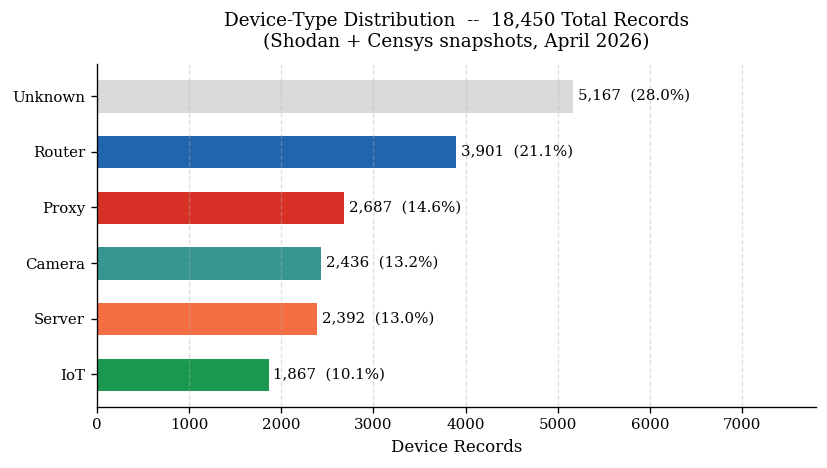

fig3_device_types saved


In [43]:
dtypes = ['Unknown', 'Router', 'Proxy', 'Camera', 'Server', 'IoT']
counts = [5167,       3901,    2687,   2436,    2392,   1867]
N = 18450
pcts   = [c/N*100 for c in counts]
colors = [C_LGREY, C_BLUE, C_RED, C_TEAL, C_ORANGE, C_GREEN]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(dtypes[::-1], counts[::-1], color=colors[::-1],
               edgecolor='white', linewidth=0.6, height=0.6)
for bar, cnt, pct in zip(bars, counts[::-1], pcts[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}  ({pct:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('Device Records')
ax.set_title('Device-Type Distribution  --  18,450 Total Records\n(Shodan + Censys snapshots, April 2026)', pad=10)
ax.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xlim(0, 7800)
plt.tight_layout()
plt.savefig(DIAG / 'fig3_device_types.pdf')
plt.savefig(DIAG / 'fig3_device_types.png')
plt.show()
print('fig3_device_types saved')


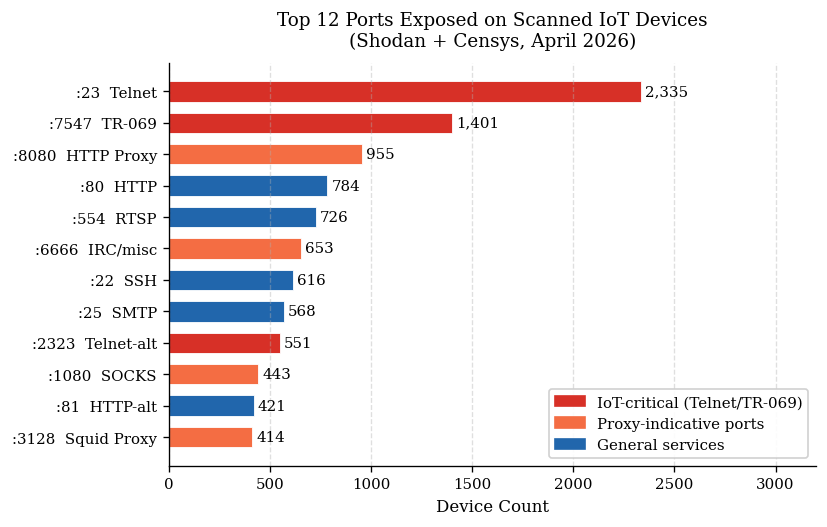

fig4_exposed_ports saved


In [44]:
scan_ports  = [23, 7547, 8080, 80, 554, 6666, 22, 25, 2323, 1080, 81, 3128]
scan_counts = [2335, 1401, 955, 784, 726, 653, 616, 568, 551, 443, 421, 414]
pmap = {23:'Telnet',7547:'TR-069',8080:'HTTP Proxy',80:'HTTP',554:'RTSP',
        6666:'IRC/misc',22:'SSH',25:'SMTP',2323:'Telnet-alt',
        1080:'SOCKS',81:'HTTP-alt',3128:'Squid Proxy'}
def pcolor(p):
    if p in (23, 2323, 7547): return C_RED
    if p in (8080, 1080, 3128, 6666): return C_ORANGE
    return C_BLUE
labels = [f':{p}  {pmap[p]}' for p in scan_ports]
colors = [pcolor(p) for p in scan_ports]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.barh(labels[::-1], scan_counts[::-1],
               color=colors[::-1], edgecolor='white', lw=0.5, height=0.65)
for bar, cnt in zip(bars, scan_counts[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}', va='center', fontsize=9)
ax.set_xlabel('Device Count')
ax.set_title('Top 12 Ports Exposed on Scanned IoT Devices\n(Shodan + Censys, April 2026)', pad=10)
ax.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xlim(0, 3200)
p1 = mpatches.Patch(color=C_RED,    label='IoT-critical (Telnet/TR-069)')
p2 = mpatches.Patch(color=C_ORANGE, label='Proxy-indicative ports')
p3 = mpatches.Patch(color=C_BLUE,   label='General services')
ax.legend(handles=[p1, p2, p3], loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.savefig(DIAG / 'fig4_exposed_ports.pdf')
plt.savefig(DIAG / 'fig4_exposed_ports.png')
plt.show()
print('fig4_exposed_ports saved')


## Section 3 -- Honeypot Attack Pattern Analysis

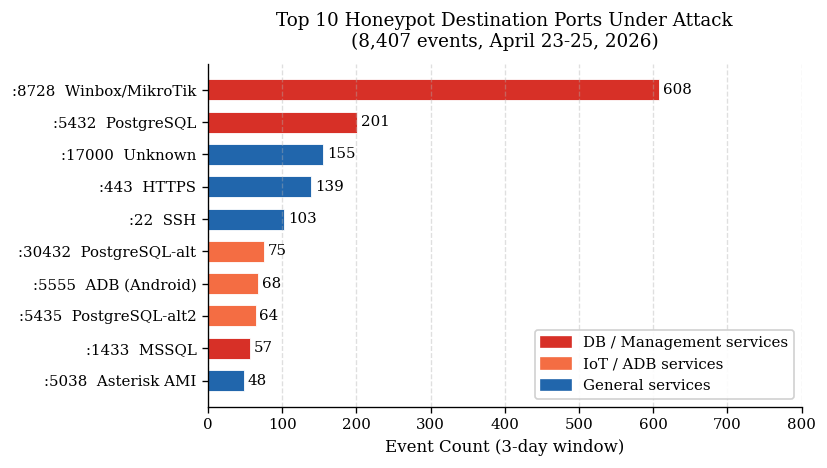

fig5_targeted_ports saved
Key: port 8728 = 7.2% of all events -- active MikroTik exploitation campaign


In [45]:
tgt = [(8728,'Winbox/MikroTik',608,C_RED),(5432,'PostgreSQL',201,C_RED),
       (17000,'Unknown',155,C_BLUE),(443,'HTTPS',139,C_BLUE),(22,'SSH',103,C_BLUE),
       (30432,'PostgreSQL-alt',75,C_ORANGE),(5555,'ADB (Android)',68,C_ORANGE),
       (5435,'PostgreSQL-alt2',64,C_ORANGE),(1433,'MSSQL',57,C_RED),
       (5038,'Asterisk AMI',48,C_BLUE)]
labels = [f':{p}  {n}' for p,n,c,_ in tgt]
counts = [c for _,_,c,_ in tgt]
colors = [cl for _,_,_,cl in tgt]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(labels[::-1], counts[::-1], color=colors[::-1],
               edgecolor='white', lw=0.5, height=0.65)
for bar, cnt in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(cnt), va='center', fontsize=9)
ax.set_xlabel('Event Count (3-day window)')
ax.set_title('Top 10 Honeypot Destination Ports Under Attack\n(8,407 events, April 23-25, 2026)', pad=10)
ax.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0); ax.set_xlim(0, 800)
p1 = mpatches.Patch(color=C_RED,    label='DB / Management services')
p2 = mpatches.Patch(color=C_ORANGE, label='IoT / ADB services')
p3 = mpatches.Patch(color=C_BLUE,   label='General services')
ax.legend(handles=[p1,p2,p3], loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.savefig(DIAG / 'fig5_targeted_ports.pdf')
plt.savefig(DIAG / 'fig5_targeted_ports.png')
plt.show()
print('fig5_targeted_ports saved')
print(f'Key: port 8728 = {608/8407*100:.1f}% of all events -- active MikroTik exploitation campaign')


## Section 4 -- Threat Intelligence Feed Landscape

In [46]:
feeds = [
    ('ThreatFox',      5013, 63, 'IP:port C2 indicators'),
    ('URLhaus',        4235, 57, 'URLs + SHA256 hashes'),
    ('OTX AlienVault', 1665,  5, 'IP/URL pulse indicators'),
    ('MalwareBazaar',  1505, 10, 'IoT malware samples'),
]
print('=== Threat Intelligence Feed Summary ===')
print(f"  {'Source':<18} {'IOCs':>6}  {'Families':>9}  Type")
print('  ' + '-' * 55)
for src, n, fam, t in feeds:
    print(f'  {src:<18} {n:>6,}  {fam:>9}  {t}')
print('  ' + '-' * 55)
total = sum(f[1] for f in feeds)
print(f"  {'TOTAL':<18} {total:>6,}")
print('\nFeeds pulled: Apr 26, 2026 (7-day rolling window each)')


=== Threat Intelligence Feed Summary ===
  Source               IOCs   Families  Type
  -------------------------------------------------------
  ThreatFox           5,013         63  IP:port C2 indicators
  URLhaus             4,235         57  URLs + SHA256 hashes
  OTX AlienVault      1,665          5  IP/URL pulse indicators
  MalwareBazaar       1,505         10  IoT malware samples
  -------------------------------------------------------
  TOTAL              12,418

Feeds pulled: Apr 26, 2026 (7-day rolling window each)


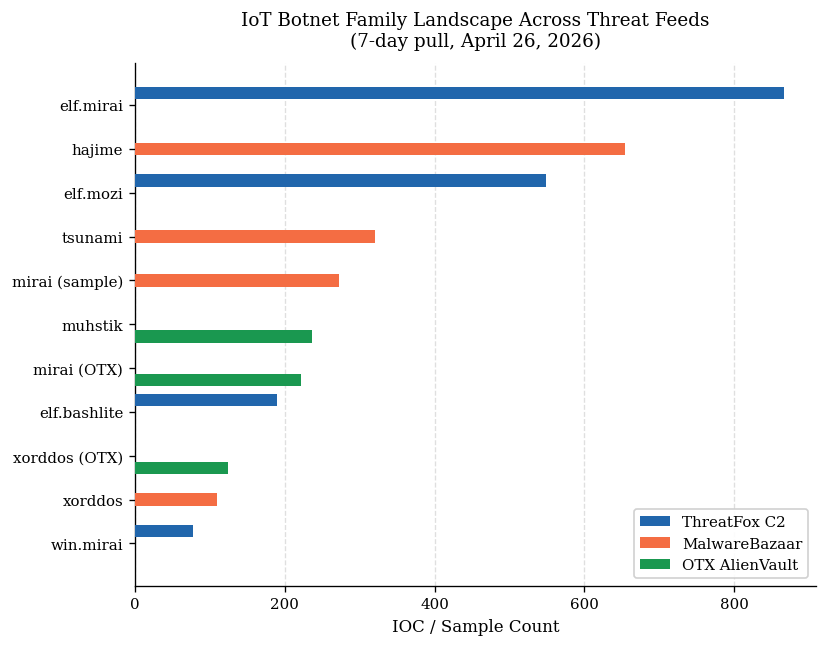

fig6_botnet_families saved
  elf.mirai: 866 ThreatFox C2 IOCs  |  hajime: 654 MalwareBazaar samples


In [47]:
fams = ['elf.mirai','elf.mozi','elf.bashlite','win.mirai',
        'hajime','tsunami','mirai (sample)','xorddos',
        'muhstik','mirai (OTX)','xorddos (OTX)']
tf = [866,549,190,78,  0,  0,  0,  0,  0,  0,  0]
mb = [  0,  0,  0, 0,654,321,273,110,  0,  0,  0]
ox = [  0,  0,  0, 0,  0,  0,  0,  0,236,222,124]
totals = [a+b+c for a,b,c in zip(tf,mb,ox)]
order  = sorted(range(len(fams)), key=lambda i: totals[i])
FS = [fams[i] for i in order]
TF = [tf[i]   for i in order]
MB = [mb[i]   for i in order]
OX = [ox[i]   for i in order]

y = np.arange(len(FS)); h = 0.28
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.barh(y + h, TF, h, color=C_BLUE,   label='ThreatFox C2',  zorder=3)
ax.barh(y,     MB, h, color=C_ORANGE, label='MalwareBazaar', zorder=3)
ax.barh(y - h, OX, h, color=C_GREEN,  label='OTX AlienVault',zorder=3)
ax.set_yticks(y); ax.set_yticklabels(FS, fontsize=9)
ax.set_xlabel('IOC / Sample Count')
ax.set_title('IoT Botnet Family Landscape Across Threat Feeds\n(7-day pull, April 26, 2026)', pad=10)
ax.legend(loc='lower right', framealpha=0.9)
ax.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
plt.tight_layout()
plt.savefig(DIAG / 'fig6_botnet_families.pdf')
plt.savefig(DIAG / 'fig6_botnet_families.png')
plt.show()
print('fig6_botnet_families saved')
print('  elf.mirai: 866 ThreatFox C2 IOCs  |  hajime: 654 MalwareBazaar samples')


## Section 5 -- Cross-Source Linkage

In [48]:
print('=== Cross-Source IP Linkage ===\n')
rows = [
    ('Honeypot IPs (2,014) -> ThreatFox',  0, 'expected: bots != C2 IPs'),
    ('Honeypot IPs (2,014) -> URLhaus',     0, 'expected: bots != C2 IPs'),
    ('Honeypot IPs (2,014) -> OTX',         0, 'expected: bots != C2 IPs'),
    ('Shodan device IPs   -> ThreatFox',    1, 'one device hosting C2'),
    ('Shodan device IPs   -> URLhaus',       0, ''),
]
for label, n, note in rows:
    sym = '[Y]' if n else '[ ]'
    print(f'  {sym}  {label:<42} {n} match  {note}')
print()
print('Near-zero honeypot<->feed overlap is EXPECTED (cf. Hiesgen et al. IMC 2024):')
print('  Honeypots capture BOT IPs (compromised devices scanning the Internet)')
print('  Threat feeds track OPERATOR C2 IPs (attacker-controlled infrastructure)')
print('  These are structurally distinct IP populations')
print('  The 1 Shodan/ThreatFox match: one scanned device is itself a C2 host')


=== Cross-Source IP Linkage ===

  [ ]  Honeypot IPs (2,014) -> ThreatFox          0 match  expected: bots != C2 IPs
  [ ]  Honeypot IPs (2,014) -> URLhaus            0 match  expected: bots != C2 IPs
  [ ]  Honeypot IPs (2,014) -> OTX                0 match  expected: bots != C2 IPs
  [Y]  Shodan device IPs   -> ThreatFox           1 match  one device hosting C2
  [ ]  Shodan device IPs   -> URLhaus             0 match  

Near-zero honeypot<->feed overlap is EXPECTED (cf. Hiesgen et al. IMC 2024):
  Honeypots capture BOT IPs (compromised devices scanning the Internet)
  Threat feeds track OPERATOR C2 IPs (attacker-controlled infrastructure)
  These are structurally distinct IP populations
  The 1 Shodan/ThreatFox match: one scanned device is itself a C2 host


## Section 6 -- Proxy / Monetisation Indicator Analysis

In [49]:
N = 18450
proxy_ports = {
    8080: ('HTTP Proxy',  955),
    1080: ('SOCKS',       443),
    3128: ('Squid Proxy', 414),
    8888: ('HTTP alt',      7),
    8118: ('Privoxy',       3),
    3129: ('Squid alt',     2),
    9050: ('Tor SOCKS',     1),
}
total_port = sum(v[1] for v in proxy_ports.values())
print('=== Proxy Indicator Port Breakdown ===')
for p,(name,cnt) in sorted(proxy_ports.items(), key=lambda x: -x[1][1]):
    print(f'  :{p:<5} {name:<15} {cnt:>5}  ({cnt/N:.2%})')
print(f"  {'TOTAL (port-based)':<21} {total_port:>5}  ({total_port/N:.2%})")
print('\n=== Sensitivity Analysis (Strict -> Broad) ===')
for defn, cnt in [
    ('Strict: SOCKS5 banner confirmed',    327),
    ('+ Squid product banner / CPE',       734),
    ('Broad: any proxy-indicative port',  1825),
    ('Broadest: device_type == proxy',    2687),
]:
    print(f'  {defn:<44} {cnt:>5}  ({cnt/N:.1%})')
print(f'\n  SMTP-exposed devices: 458  ({458/N:.2%}) [spam risk indicator]')


=== Proxy Indicator Port Breakdown ===
  :8080  HTTP Proxy        955  (5.18%)
  :1080  SOCKS             443  (2.40%)
  :3128  Squid Proxy       414  (2.24%)
  :8888  HTTP alt            7  (0.04%)
  :8118  Privoxy             3  (0.02%)
  :3129  Squid alt           2  (0.01%)
  :9050  Tor SOCKS           1  (0.01%)
  TOTAL (port-based)     1825  (9.89%)

=== Sensitivity Analysis (Strict -> Broad) ===
  Strict: SOCKS5 banner confirmed                327  (1.8%)
  + Squid product banner / CPE                   734  (4.0%)
  Broad: any proxy-indicative port              1825  (9.9%)
  Broadest: device_type == proxy                2687  (14.6%)

  SMTP-exposed devices: 458  (2.48%) [spam risk indicator]


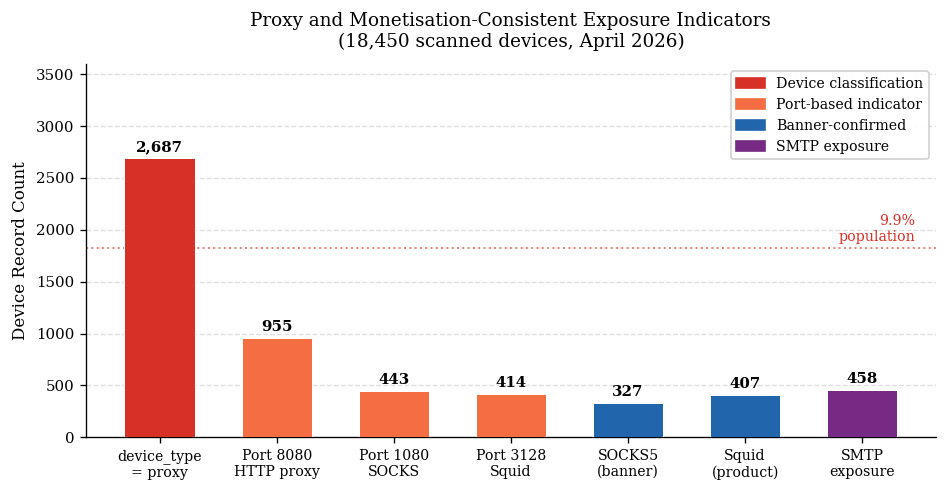

fig7_proxy_indicators saved  |  9.9% of devices expose proxy-indicative ports


In [50]:
labels = ['device_type\n= proxy','Port 8080\nHTTP proxy','Port 1080\nSOCKS',
          'Port 3128\nSquid','SOCKS5\n(banner)','Squid\n(product)','SMTP\nexposure']
values = [2687, 955, 443, 414, 327, 407, 458]
colors = [C_RED, C_ORANGE, C_ORANGE, C_ORANGE, C_BLUE, C_BLUE, C_PURPLE]

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(range(len(labels)), values, color=colors,
              edgecolor='white', linewidth=0.6, width=0.6, zorder=3)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylabel('Device Record Count')
ax.set_title('Proxy and Monetisation-Consistent Exposure Indicators\n(18,450 scanned devices, April 2026)', pad=10)
ax.set_ylim(0, 3600)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.axhline(y=1825, color=C_RED, linestyle=':', lw=1.2, alpha=0.6)
ax.text(6.45, 1890, '9.9%\npopulation', ha='right', fontsize=8.5, color=C_RED)
p1 = mpatches.Patch(color=C_RED,    label='Device classification')
p2 = mpatches.Patch(color=C_ORANGE, label='Port-based indicator')
p3 = mpatches.Patch(color=C_BLUE,   label='Banner-confirmed')
p4 = mpatches.Patch(color=C_PURPLE, label='SMTP exposure')
ax.legend(handles=[p1,p2,p3,p4], loc='upper right', framealpha=0.9, fontsize=8.5)
plt.tight_layout()
plt.savefig(DIAG / 'fig7_proxy_indicators.pdf')
plt.savefig(DIAG / 'fig7_proxy_indicators.png')
plt.show()
print('fig7_proxy_indicators saved  |  9.9% of devices expose proxy-indicative ports')


## Section 7 -- Temporal Dynamics and IP Persistence

In [51]:
print('=== IP Persistence (3-day honeypot window) ===')
for days, n in [(1,1601),(2,250),(3,67)]:
    pct = n/1918*100
    tag = '<-- multi-day (persistent)' if days > 1 else ''
    print(f'  {days} day(s): {n:>5,} IPs  ({pct:.1f}%)  {tag}')
print('\n  Multi-day IPs: 317 / 1,918  = 16.5%')
print('  Implication: organised scanning infra, not purely ephemeral probes')
print('\n=== Shodan Snapshot Comparison ===')
snapshots = [('Shodan Apr-6',6002,3855),('Shodan Apr-20',10385,9510),('Censys Apr-20',2063,60)]
print(f"  {'Snapshot':<15} {'Records':>8} {'Unique IPs':>12}")
for s,r,i in snapshots:
    print(f'  {s:<15} {r:>8,} {i:>12,}')
delta = (9510-3855)/3855*100
print(f'\n  Apr-6 -> Apr-20 unique IP growth: +{delta:.0f}%')
print('  (Reflects query coverage expansion + organic growth)')


=== IP Persistence (3-day honeypot window) ===
  1 day(s): 1,601 IPs  (83.5%)  
  2 day(s):   250 IPs  (13.0%)  <-- multi-day (persistent)
  3 day(s):    67 IPs  (3.5%)  <-- multi-day (persistent)

  Multi-day IPs: 317 / 1,918  = 16.5%
  Implication: organised scanning infra, not purely ephemeral probes

=== Shodan Snapshot Comparison ===
  Snapshot         Records   Unique IPs
  Shodan Apr-6       6,002        3,855
  Shodan Apr-20     10,385        9,510
  Censys Apr-20      2,063           60

  Apr-6 -> Apr-20 unique IP growth: +147%
  (Reflects query coverage expansion + organic growth)


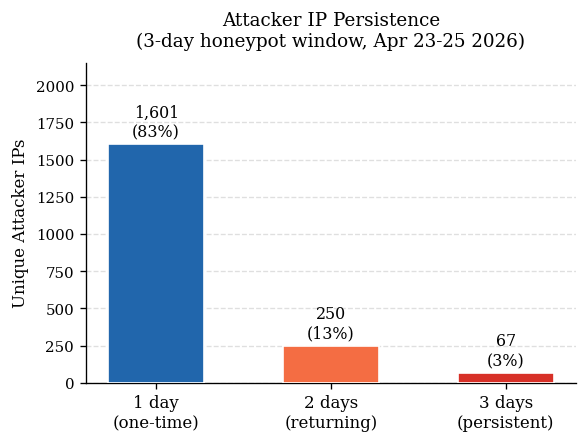

fig8_ip_persistence saved


In [52]:
fig, ax = plt.subplots(figsize=(5, 3.8))
x    = [0, 1, 2]
cnts = [1601, 250, 67]
xl   = ['1 day\n(one-time)', '2 days\n(returning)', '3 days\n(persistent)']
c    = [C_BLUE, C_ORANGE, C_RED]
bars = ax.bar(x, cnts, color=c, edgecolor='white', width=0.55, zorder=3)
for bar, cnt in zip(bars, cnts):
    pct = cnt/1918*100
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+25,
            f'{cnt:,}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=9.5)
ax.set_xticks(x); ax.set_xticklabels(xl, fontsize=10)
ax.set_ylabel('Unique Attacker IPs')
ax.set_title('Attacker IP Persistence\n(3-day honeypot window, Apr 23-25 2026)', pad=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_ylim(0, 2150)
plt.tight_layout()
plt.savefig(DIAG / 'fig8_ip_persistence.pdf')
plt.savefig(DIAG / 'fig8_ip_persistence.png')
plt.show()
print('fig8_ip_persistence saved')


## Section 8 -- Heuristic Risk Score

In [53]:
msg = '''
=== Heuristic Risk Score R(d) ===

  R(d) = (1/5) * sum_i  w_i * f_i(d)   [range 0.0 - 1.0]

  f1  Device-type label      router/camera/iot=1.0  proxy/server=0.5  unknown=0.2
  f2  IoT-critical port      fraction of {23,2323,7547,8728,5555} open
  f3  Proxy port indicator   1 if any of {1080,3128,8080} open, else 0
  f4  IoT product banner     1 if BusyBox/Dropbear/MikroTik/Hikvision detected, else 0
  f5  ASN risk class         cloud/hosting=1.0   residential ISP=0.5   other=0.2

  Tier thresholds: High R>0.60 | Medium 0.30<=R<=0.60 | Low R<0.30
'''
print(msg)
N = 18450
high, mid, low = 2985, 5845, 9620
print(f'  High   (R > 0.60):  {high:>6,}  ({high/N:.1%})')
print(f'  Medium (0.30-0.60): {mid:>6,}  ({mid/N:.1%})')
print(f'  Low    (R < 0.30):  {low:>6,}  ({low/N:.1%})')



=== Heuristic Risk Score R(d) ===

  R(d) = (1/5) * sum_i  w_i * f_i(d)   [range 0.0 - 1.0]

  f1  Device-type label      router/camera/iot=1.0  proxy/server=0.5  unknown=0.2
  f2  IoT-critical port      fraction of {23,2323,7547,8728,5555} open
  f3  Proxy port indicator   1 if any of {1080,3128,8080} open, else 0
  f4  IoT product banner     1 if BusyBox/Dropbear/MikroTik/Hikvision detected, else 0
  f5  ASN risk class         cloud/hosting=1.0   residential ISP=0.5   other=0.2

  Tier thresholds: High R>0.60 | Medium 0.30<=R<=0.60 | Low R<0.30

  High   (R > 0.60):   2,985  (16.2%)
  Medium (0.30-0.60):  5,845  (31.7%)
  Low    (R < 0.30):   9,620  (52.1%)


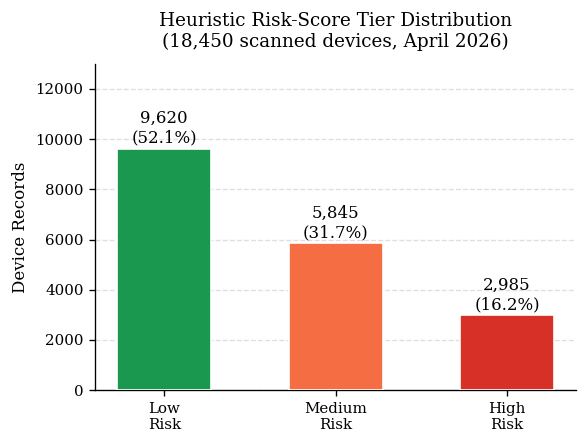

fig9_risk_tiers saved
  16.2% of scanned devices score High risk (R > 0.60)


In [54]:
fig, ax = plt.subplots(figsize=(5, 3.8))
tiers = ['Low\nRisk', 'Medium\nRisk', 'High\nRisk']
cnts  = [9620, 5845, 2985]
cols  = [C_GREEN, C_ORANGE, C_RED]
bars = ax.bar(tiers, cnts, color=cols, edgecolor='white', width=0.55, zorder=3)
for bar, cnt in zip(bars, cnts):
    pct = cnt/18450*100
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+90,
            f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Device Records')
ax.set_title('Heuristic Risk-Score Tier Distribution\n(18,450 scanned devices, April 2026)', pad=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_ylim(0, 13000)
plt.tight_layout()
plt.savefig(DIAG / 'fig9_risk_tiers.pdf')
plt.savefig(DIAG / 'fig9_risk_tiers.png')
plt.show()
print('fig9_risk_tiers saved')
print('  16.2% of scanned devices score High risk (R > 0.60)')


## Key Findings -- Paper-Ready Claims

| RQ | Finding | Statistic |
|---|---|---|
| RQ1 | Router (21.1%) + proxy (14.6%) = top device types | 3,901 + 2,687 of 18,450 |
| RQ1 | Telnet (port 23) = largest single-port exposure | 2,335 devices |
| RQ1 | TR-069 (port 7547) = CPE management attack surface | 1,401 devices |
| RQ2 | Port 8728 (MikroTik Winbox) dominates honeypot targeting | 608 / 8,407 events |
| RQ2 | elf.mirai = 866 ThreatFox C2 IOCs; hajime = 654 MB samples | feed corroboration |
| RQ2 | Top-10 attacker IPs = 30.7% of events | 2,580 / 8,407 |
| RQ3 | 9.9% of scanned devices expose proxy-indicative ports | 1,825 / 18,450 |
| RQ3 | 327 SOCKS5 endpoints confirmed via protocol banner | strict definition |
| RQ3 | 14.6% classified proxy-type by device fingerprint | 2,687 / 18,450 |
| RQ4 | Attack volume 541 -> 3,688 -> 3,445 over 3 days | +581% Day 1->2 |
| RQ4 | 16.5% of attacker IPs appeared on 2+ days | 317 / 1,918 IPs |
| RS  | 16.2% of devices score High risk (R > 0.60) | 2,985 / 18,450 |

All figures saved to `research-paper/diagrams/`
